In [2]:
N_CONT = 10000  # размер выборок для непрерывных
N_DISC = 10000  # размер выборок для дискретных
import math, numpy as np, matplotlib.pyplot as plt, pandas as pd

np.random.seed(12345)


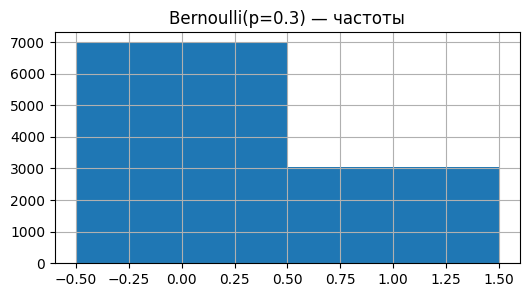

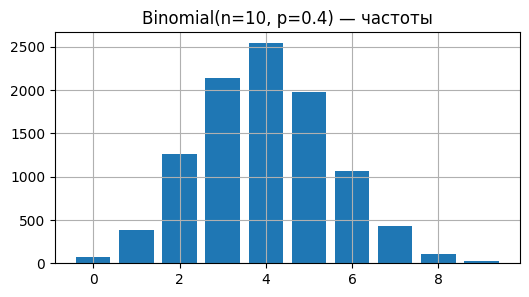

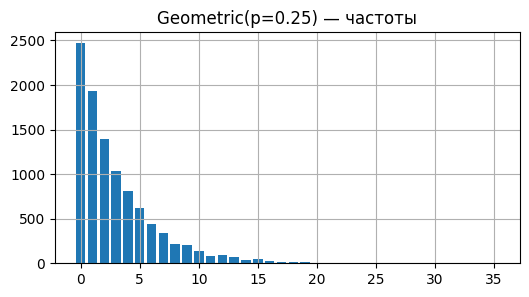

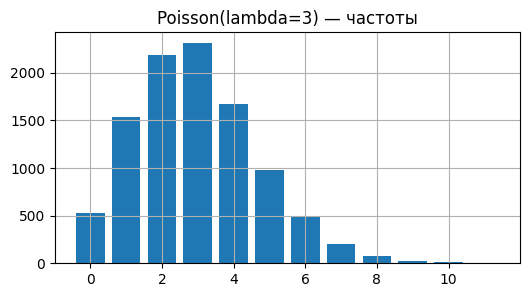

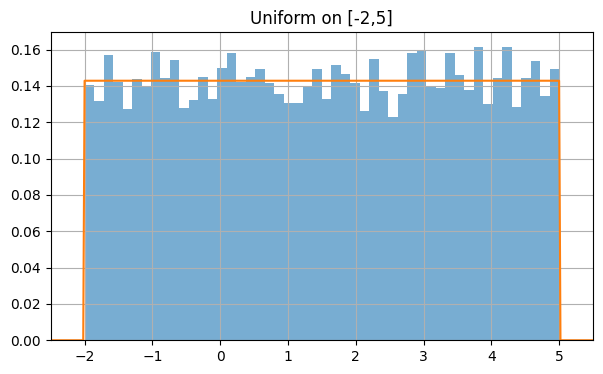

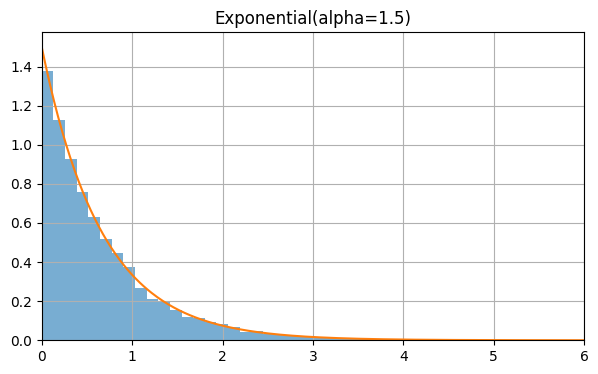

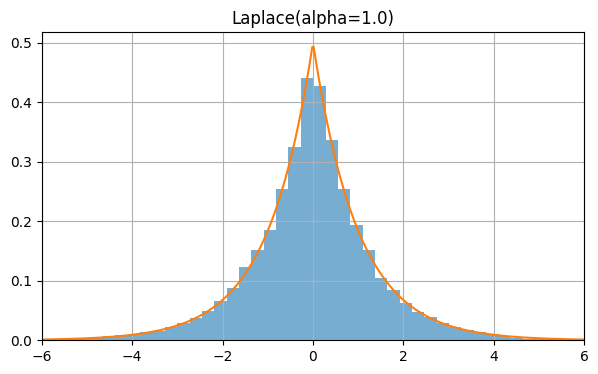

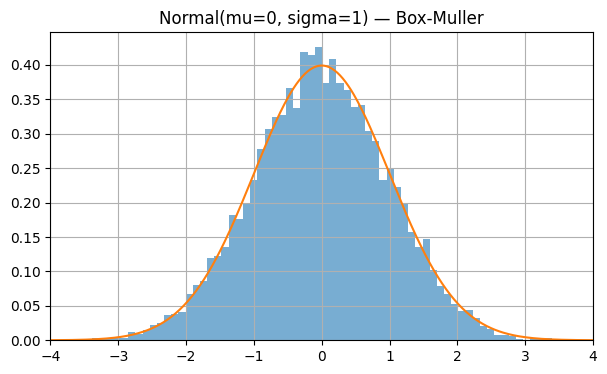

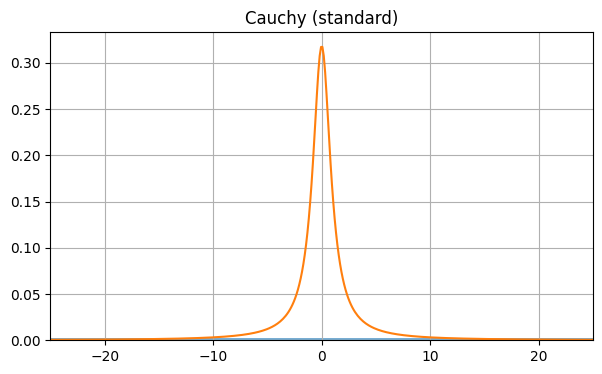

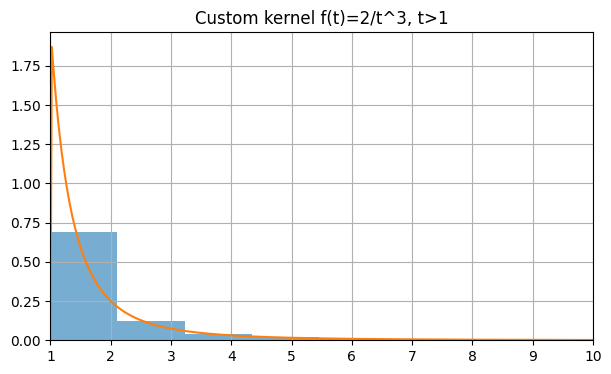

In [4]:
# ========== 1) Реализация генераторов на базе U ~ Uniform(0,1) ==========
def bernoulli(p):
    u = np.random.random()
    return 1 if u < p else 0

def bernoulli_sample(p, size):
    u = np.random.random(size)
    return (u < p).astype(int)

def binomial_sample(n, p, size):
    # сумма n Бернулли
    u = np.random.random((size, n))
    return (u < p).sum(axis=1)

def geometric_failures_sample(p, size):
    res = np.zeros(size, dtype=int)
    for i in range(size):
        k = 0
        while True:
            if np.random.random() < p:  # успех
                res[i] = k
                break
            else:                       # неудача
                k += 1
    return res

def poisson_sample(lmbda, size):
    # метод инверсии: аккумулируем вероятности
    result = np.empty(size, dtype=int)
    for i in range(size):
        L = math.exp(-lmbda)
        p = L
        k = 0
        u = np.random.random()
        cum = p
        while u > cum:
            k += 1
            p *= lmbda / k
            cum += p
        result[i] = k
    return result

def uniform_ab_sample(a, b, size):
    u = np.random.random(size)
    return a + (b-a)*u

def exponential_sample(alpha, size):
    # density alpha * exp(-alpha x), x>=0
    u = np.random.random(size)
    return -np.log(u)/alpha

def laplace_sample(alpha, size):
    # (alpha/2) exp(-alpha |x|)
    u = np.random.random(size)
    x = np.where(u < 0.5,
                 (1/alpha)*np.log(2*u),
                 -(1/alpha)*np.log(2*(1-u)))
    return x

def normal_box_muller(mu, sigma, size):
    # Box-Muller transform using pairs of uniforms
    u1 = np.random.random(size//2 + size%2)
    u2 = np.random.random(size//2 + size%2)
    z1 = np.sqrt(-2*np.log(u1)) * np.cos(2*np.pi*u2)
    z2 = np.sqrt(-2*np.log(u1)) * np.sin(2*np.pi*u2)
    z = np.concatenate([z1, z2])[:size]
    return mu + sigma*z

def cauchy_sample(size):
    u = np.random.random(size)
    return np.tan(np.pi*(u-0.5))

def custom_kernel_sample(size):
    # f(t) = C * 1/t^3 for t>1, normalized -> C=2, CDF F(x)=0 for x<=1, 1-1/x^2 for x>1
    # inverse: x = 1/sqrt(1-U)
    u = np.random.random(size)
    return 1.0/np.sqrt(1-u)

# ========== Визуализация: гистограммы + теоретические плотности ==========

def plot_histogram_with_pdf(samples, title, bins=100, density=True, xlim=None, pdf_func=None):
    plt.figure(figsize=(7,4))
    plt.hist(samples, bins=bins, density=density, alpha=0.6)
    if pdf_func is not None:
        xs = np.linspace(xlim[0] if xlim else samples.min(), xlim[1] if xlim else samples.max(), 400)
        ys = np.array([pdf_func(x) for x in xs])
        plt.plot(xs, ys)  # overlay theoretical density
    plt.title(title)
    if xlim:
        plt.xlim(xlim)
    plt.grid(True)
    plt.show()

# Генерируем выборки и строим гистограммы для всех пунктов задания №1
# Дискретные:
bern = bernoulli_sample(0.3, N_DISC)
binom = binomial_sample(10, 0.4, N_DISC)
geom = geometric_failures_sample(0.25, N_DISC)
pois = poisson_sample(3.0, N_DISC)

# Непрерывные:
unif = uniform_ab_sample(-2, 5, N_CONT)
exp_s = exponential_sample(1.5, N_CONT)
lap = laplace_sample(1.0, N_CONT)
norm = normal_box_muller(0.0, 1.0, N_CONT)
cau = cauchy_sample(N_CONT)
cust = custom_kernel_sample(N_CONT)

# Отобразим гистограммы (по одной фигуре на распределение)
# Дискретные: будем показывать bar-like гистограммы (bins=range)
plt.figure(figsize=(6,3))
plt.hist(bern, bins=[-0.5,0.5,1.5], density=False)
plt.title('Bernoulli(p=0.3) — частоты')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(binom, bins=range(0, 11), align='left', rwidth=0.8)
plt.title('Binomial(n=10, p=0.4) — частоты')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(
    geom,
    bins=range(0, max(geom) + 2),
    align='left',
    rwidth=0.8
)
plt.title('Geometric(p=0.25) — частоты')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,3))
plt.hist(pois, bins=range(0, max(pois)+2), align='left', rwidth=0.8)
plt.title('Poisson(lambda=3) — частоты')
plt.grid(True)
plt.show()

# Непрерывные с теоретическими плотностями
# Uniform on [a,b]:
plot_histogram_with_pdf(unif, 'Uniform on [-2,5]', bins=50, density=True, xlim=[-2.5,5.5],
                        pdf_func=lambda x: 1.0/(5-(-2)) if -2<=x<=5 else 0.0)

# Exponential:
plot_histogram_with_pdf(exp_s, 'Exponential(alpha=1.5)', bins=50, density=True, xlim=[0,6],
                        pdf_func=lambda x: 1.5*math.exp(-1.5*x) if x>=0 else 0.0)

# Laplace:
plot_histogram_with_pdf(lap, 'Laplace(alpha=1.0)', bins=80, density=True, xlim=[-6,6],
                        pdf_func=lambda x: 0.5*1.0*math.exp(-1.0*abs(x)))

# Normal (Box-Muller) vs standard normal pdf:
plot_histogram_with_pdf(norm, 'Normal(mu=0, sigma=1) — Box-Muller', bins=80, density=True, xlim=[-4,4],
                        pdf_func=lambda x: (1/math.sqrt(2*math.pi))*math.exp(-x*x/2))

# Cauchy:
plot_histogram_with_pdf(cau, 'Cauchy (standard)', bins=200, density=True, xlim=[-25,25],
                        pdf_func=lambda x: 1/(math.pi*(1+x*x)))

# Custom kernel f(t)=2/t^3 for t>1:
plot_histogram_with_pdf(cust, 'Custom kernel f(t)=2/t^3, t>1', bins=100, density=True, xlim=[1,10],
                        pdf_func=lambda x: (2/(x**3) if x>1 else 0.0))


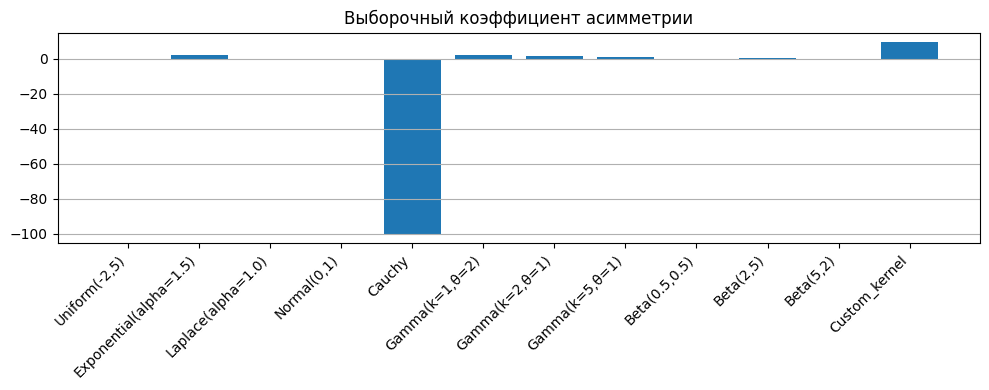

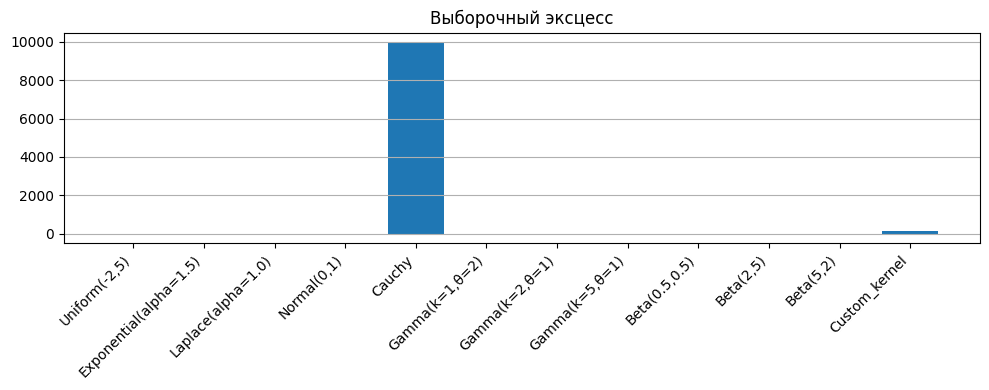

In [5]:
# ========== 2) Выборочные характеристики: асимметрия и эксцесс ==========
def sample_moments(x):
    n = x.size
    mean = x.mean()
    m2 = np.mean((x-mean)**2)
    m3 = np.mean((x-mean)**3)
    m4 = np.mean((x-mean)**4)
    skew = m3 / (m2**1.5) if m2>0 else np.nan
    excess = m4 / (m2**2) - 3 if m2>0 else np.nan
    return mean, m2, skew, excess

# Список распределений для исследования (включая гамма и бета)
from numpy.random import default_rng
rng = default_rng(12345)
# Gamma (shape k, scale theta)
gamma1 = rng.gamma(shape=1.0, scale=2.0, size=N_CONT)  # mean=2
gamma2 = rng.gamma(shape=2.0, scale=1.0, size=N_CONT)  # mean=2
gamma5 = rng.gamma(shape=5.0, scale=1.0, size=N_CONT)  # mean=5

# Beta distributions:
beta1 = rng.beta(0.5, 0.5, size=N_CONT)
beta2 = rng.beta(2.0, 5.0, size=N_CONT)
beta3 = rng.beta(5.0, 2.0, size=N_CONT)

# Assemble table
rows = []
names = ['Uniform(-2,5)','Exponential(alpha=1.5)','Laplace(alpha=1.0)','Normal(0,1)','Cauchy','Gamma(k=1,θ=2)',
         'Gamma(k=2,θ=1)','Gamma(k=5,θ=1)','Beta(0.5,0.5)','Beta(2,5)','Beta(5,2)','Custom_kernel']
samples_dict = {
    'Uniform(-2,5)': unif, 'Exponential(alpha=1.5)': exp_s, 'Laplace(alpha=1.0)': lap,
    'Normal(0,1)': norm, 'Cauchy': cau, 'Gamma(k=1,θ=2)': gamma1, 'Gamma(k=2,θ=1)': gamma2,
    'Gamma(k=5,θ=1)': gamma5, 'Beta(0.5,0.5)': beta1, 'Beta(2,5)': beta2, 'Beta(5,2)': beta3,
    'Custom_kernel': cust
}
for name, arr in samples_dict.items():
    mean, var, skew, excess = sample_moments(arr)
    rows.append({'Distribution': name, 'Mean': mean, 'Var (1/n)': var, 'Skewness': skew, 'Excess kurtosis': excess})
df_moments = pd.DataFrame(rows).set_index('Distribution')

# --- 1. Визуализация асимметрии ---
plt.figure(figsize=(10, 4))
plt.bar(df_moments.index, df_moments['Skewness'])
plt.xticks(rotation=45, ha='right')
plt.title('Выборочный коэффициент асимметрии')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# --- 2. Визуализация эксцесса ---
plt.figure(figsize=(10, 4))
plt.bar(df_moments.index, df_moments['Excess kurtosis'])
plt.xticks(rotation=45, ha='right')
plt.title('Выборочный эксцесс')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


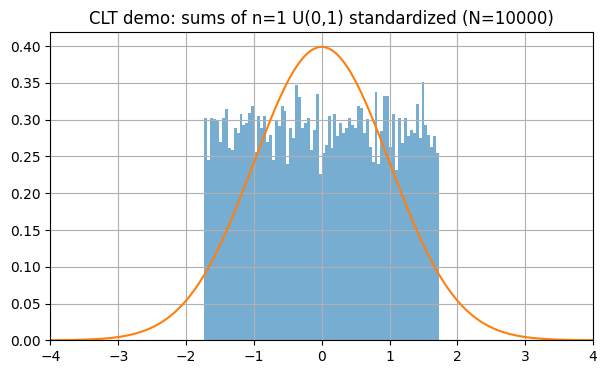

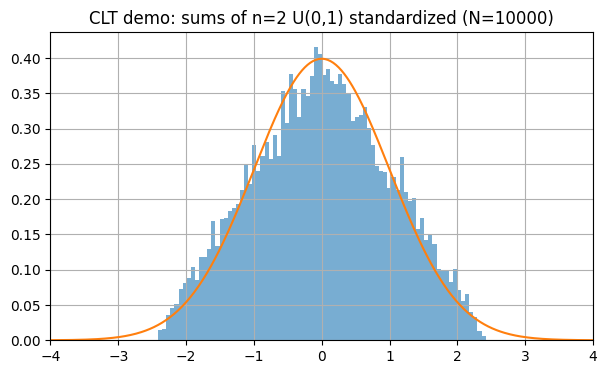

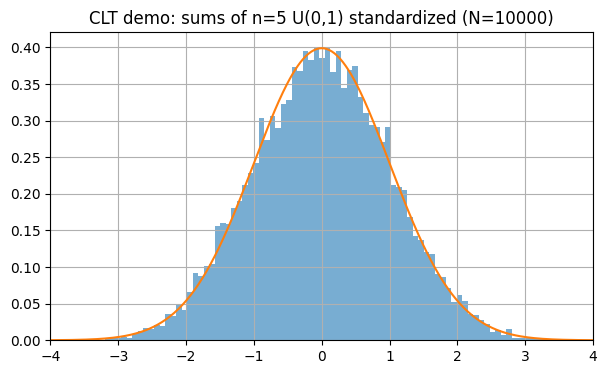

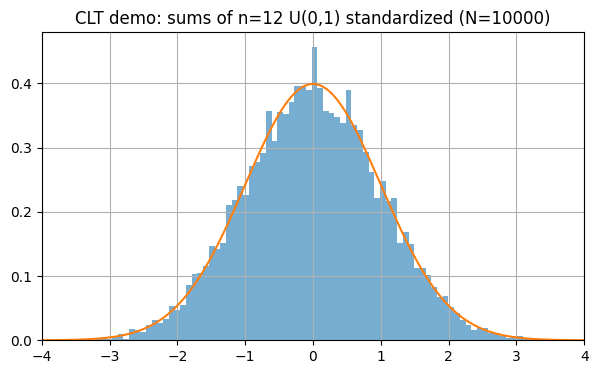

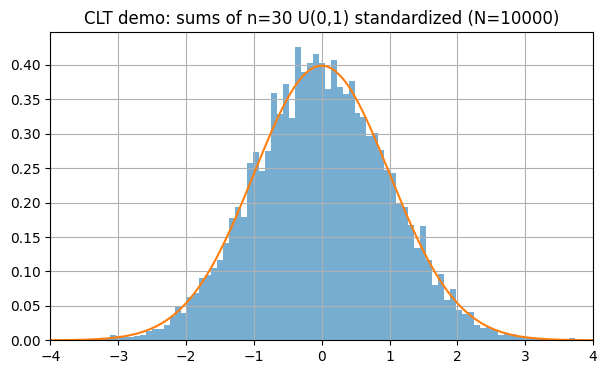

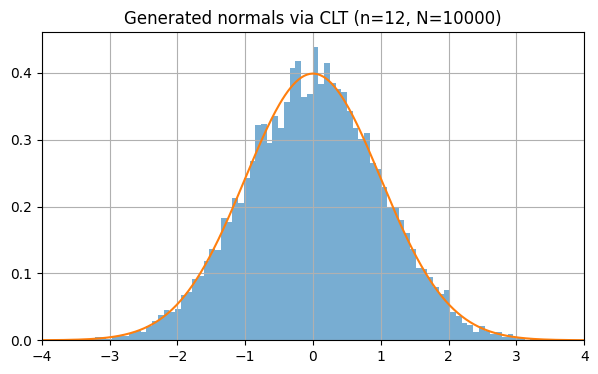

Таблица выборочных моментов отображена выше как интерактивная таблица.


In [6]:
# ========== 3) Центральная предельная теорема (демонстрация) ==========
# Функция, создающая N выборок стандартизированных сумм n iid U(0,1)
def clt_from_uniform(n, N):
    # ξ_i ~ U(0,1) with mean 0.5 and var 1/12
    Xi = np.random.random((N, n))
    sums = Xi.sum(axis=1)
    mean = n*0.5
    var = n*(1.0/12.0)
    standardized = (sums - mean) / np.sqrt(var)
    return standardized

# Покажем для нескольких n
ns = [1,2,5,12,30]
Nclt = 10000
for n in ns:
    vals = clt_from_uniform(n, Nclt)
    plot_histogram_with_pdf(vals, f'CLT demo: sums of n={n} U(0,1) standardized (N={Nclt})',
                            bins=80, density=True, xlim=[-4,4],
                            pdf_func=lambda x: (1/math.sqrt(2*math.pi))*math.exp(-x*x/2))

# Также предоставим одну функцию: генерация нормали с помощью ЦПТ (как в задании №3)
def generate_normal_by_clt(n, N):
    vals = clt_from_uniform(n, N)
    return vals

# Создадим выборку нормалей через ЦПТ с n=12, N=10000 и сравним с истинной нормалью
clt_normals = generate_normal_by_clt(12, 10000)
plot_histogram_with_pdf(clt_normals, 'Generated normals via CLT (n=12, N=10000)', bins=80, density=True, xlim=[-4,4],
                        pdf_func=lambda x: (1/math.sqrt(2*math.pi))*math.exp(-x*x/2))

# Вывод таблицы с результатами (выборочная асимметрия и эксцесс для гамма и бета при разных параметрах уже в df_moments)
print('Таблица выборочных моментов отображена выше как интерактивная таблица.')